# Heart Bio-MEM model


In [ ]:
# IMPORTACION DE LIBRERIAS
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass, field
import heapq
import wfdb
from pathlib import Path
from scipy.signal import find_peaks
import os

import math
from dataclasses import dataclass
from typing import Dict, List, Optional, Tuple

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

<h1>DataLoader para MIT-BIH</h1>

In [8]:
class MITLoader:
    def __init__(self, mit_path):
        self.mit_path = Path(mit_path)

    def load_record(self, record_name):
        try:
            record_path = self.mit_path / record_name

            record = wfdb.rdrecord(str(record_path))
            ann = wfdb.rdann(str(record_path), 'atr')

            fs = record.fs
            r_peaks = ann.sample

            if len(r_peaks) < 10:
                return None

            rr = np.diff(r_peaks) / fs
            hr = 60 / rr

            return {
                "rr": rr,
                "hr": hr,
                "hr_mean": float(np.mean(hr))
            }

        except Exception as e:
            print("Error:", e)
            return None

<h1>Cargar DataSet</h1>

In [6]:
class DataLoader:
    def __init__(self, ptb_path=None, mit_path=None):
        self.ptb_path = Path(ptb_path) if ptb_path else None
        self.mit_path = Path(mit_path) if mit_path else None

    def _extract_hr(self, record_path: Path, ann_ext: str = None) -> dict | None:
        """
        Núcleo compartido: lee un record wfdb y extrae HR.
        ann_ext: extensión de anotaciones, ej. "atr" para MIT-BIH.
                 Si es None, usa detección de picos.
        """
        try:
            record = wfdb.rdrecord(str(record_path))
            ecg_signal = record.p_signal[:, 0]
            fs = record.fs

            hr_bpm = None

            # --- Método 1: anotaciones (MIT-BIH tiene .atr) ---
            if ann_ext:
                try:
                    ann = wfdb.rdann(str(record_path), ann_ext)
                    rr_samples = np.diff(ann.sample)
                    rr_seconds = rr_samples / fs
                    valid = rr_seconds[(rr_seconds > 0.33) & (rr_seconds < 1.5)]
                    if len(valid) > 2:
                        hr_bpm = 60.0 / np.median(valid)
                        rr_mean = float(np.median(valid))
                except Exception:
                    pass  # fallback a picos

            # --- Método 2: detección de picos ---
            if hr_bpm is None:
                ecg_norm = (ecg_signal - np.mean(ecg_signal)) / np.std(ecg_signal)
                peaks, _ = find_peaks(
                    ecg_norm,
                    distance=int(0.4 * fs),   # mínimo 0.4s entre picos (~150 bpm max)
                    height=0.3,
                )
                if len(peaks) < 3:
                    return None

                rr = np.diff(peaks) / fs
                rr_valid = rr[(rr > 0.33) & (rr < 1.5)]
                if len(rr_valid) < 2:
                    return None

                hr_bpm = float(np.mean(60.0 / rr_valid))
                rr_mean = float(np.mean(rr_valid))

            # Clampear a rango fisiológico
            hr_bpm = float(np.clip(hr_bpm, 30.0, 200.0))

            return {
                "hr_mean": hr_bpm,
                "rr_mean": rr_mean,
            }

        except Exception as e:
            print(f"Error leyendo {record_path}: {e}")
            return None

    # ----------------------------------------------------------
    # PTB  (estructura: ptb_path / patient_folder / record_name)
    # ----------------------------------------------------------
    def load_ptb_record(self, patient_folder: str, record_name: str) -> dict | None:
        if self.ptb_path is None:
            raise ValueError("ptb_path no fue configurado")
        record_path = self.ptb_path / patient_folder / record_name
        return self._extract_hr(record_path, ann_ext=None)  # PTB no tiene .atr

    # ----------------------------------------------------------
    # MIT-BIH  (estructura: mit_path / record_name)
    # ----------------------------------------------------------
    def load_mit_record(self, record_name: str) -> dict | None:
        if self.mit_path is None:
            raise ValueError("mit_path no fue configurado")
        record_path = self.mit_path / record_name
        return self._extract_hr(record_path, ann_ext="atr")  # MIT-BIH sí tiene .atr

    # ----------------------------------------------------------
    # Iterar todos los records de un dataset
    # ----------------------------------------------------------
    def iter_ptb(self):
        """Genera (patient_folder, record_name, data) para todo PTB."""
        if self.ptb_path is None:
            return
        for patient_folder in sorted(self.ptb_path.iterdir()):
            if not patient_folder.is_dir():
                continue
            for dat_file in sorted(patient_folder.glob("*.dat")):
                record_name = dat_file.stem
                data = self.load_ptb_record(patient_folder.name, record_name)
                if data:
                    yield patient_folder.name, record_name, data

    def iter_mit(self):
        """Genera (record_name, data) para todo MIT-BIH."""
        if self.mit_path is None:
            return
        for dat_file in sorted(self.mit_path.glob("*.dat")):
            record_name = dat_file.stem
            data = self.load_mit_record(record_name)
            if data:
                yield record_name, data

<h2>Lectura de los Dataset</h2>

In [30]:
class RealECGDataset(Dataset):
    def __init__(self, root_dir, T=500):
        self.T = T
        self.records = []

        mit_path = os.path.join(root_dir, "mit-bih-arrhythmia-database-1.0.0")
        ptb_path = os.path.join(root_dir, "ptb-diagnostic-ecg-database-1.0.0")

        # ======================
        # MIT-BIH
        # ======================
        for file in os.listdir(mit_path):
            if file.endswith(".dat"):
                record_name = file.replace(".dat", "")
                self.records.append(os.path.join(mit_path, record_name))

        # ======================
        # PTB (carpetas anidadas)
        # ======================
        for root, _, files in os.walk(ptb_path):
            for f in files:
                if f.endswith(".dat"):
                    record_name = f.replace(".dat", "")
                    self.records.append(os.path.join(root, record_name))

        print("✅ Total records encontrados:", len(self.records))

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        record_path = self.records[idx]

        try:
            record = wfdb.rdrecord(record_path)
            signal = record.p_signal
        except Exception as e:
            print("Error leyendo:", record_path)
            return self.__getitem__((idx + 1) % len(self))

        # cortar o pad
        signal = signal[:self.T]

        if signal.shape[0] < self.T:
            pad = np.zeros((self.T - signal.shape[0], signal.shape[1]))
            signal = np.vstack([signal, pad])

        ecg = torch.tensor(signal, dtype=torch.float32)

        # ⚠️ IMPORTANTE: algunos tienen <12 canales
        if ecg.shape[1] < 12:
            pad = torch.zeros(self.T, 12 - ecg.shape[1])
            ecg = torch.cat([ecg, pad], dim=1)

        ecg = ecg[:, :12]

        # ===== FAKE PPG ===== (luego lo mejoramos)
        ppg = ecg[:, 0]
        dppg = torch.diff(ppg, prepend=ppg[:1])
        ddppg = torch.diff(dppg, prepend=dppg[:1])

        spo2 = torch.ones_like(ppg) * 0.97
        perf = torch.ones_like(ppg) * 0.5

        x = torch.stack([ppg, dppg, ddppg, spo2, perf], dim=-1)

        return x, ecg

<h1>Codigo base 1</h1>


Segment activation delays (s):
RV_freewall  | RV | 0.1680
RV_apex      | RV | 0.1680
RV_septal    | RV | 0.1680
RV_base      | RV | 0.1680
LV_septal    | LV | 0.1700
LV_apex      | LV | 0.1700
LV_lateral   | LV | 0.1700
LV_anterior  | LV | 0.1700
LV_posterior | LV | 0.1700
LV_base      | LV | 0.1700


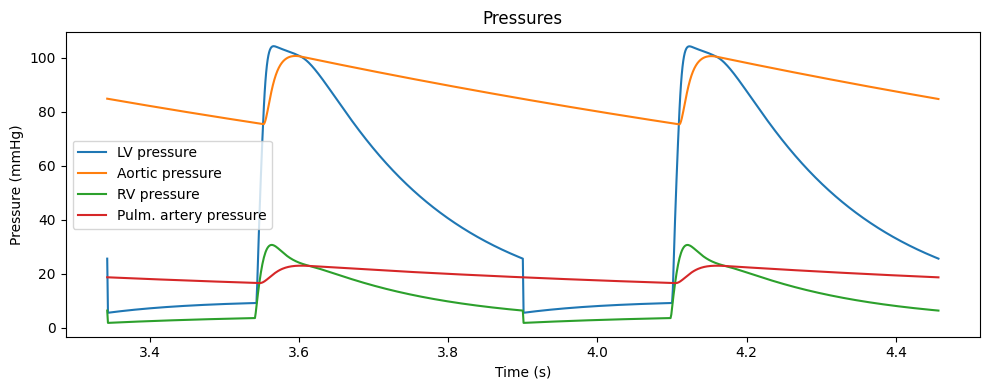

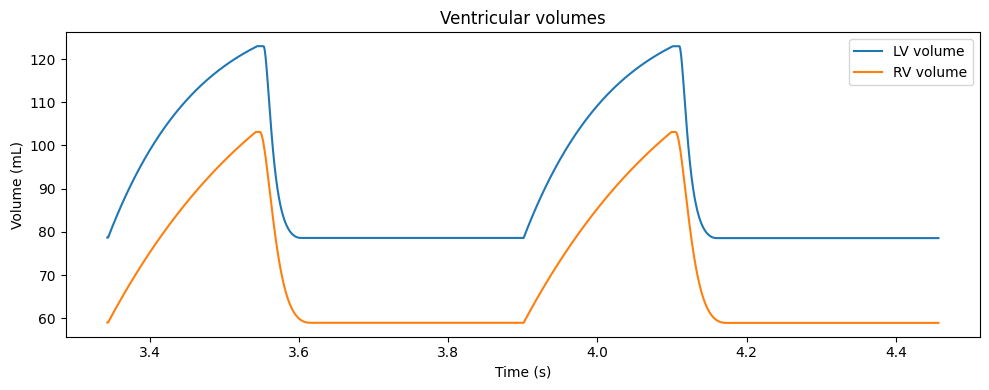

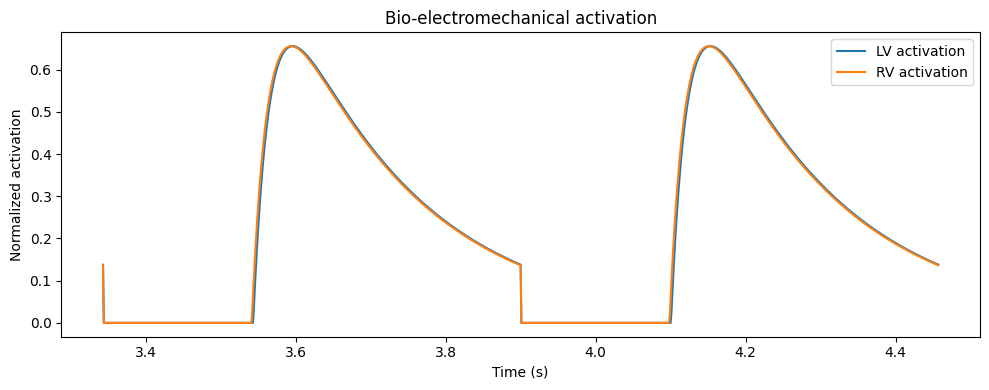

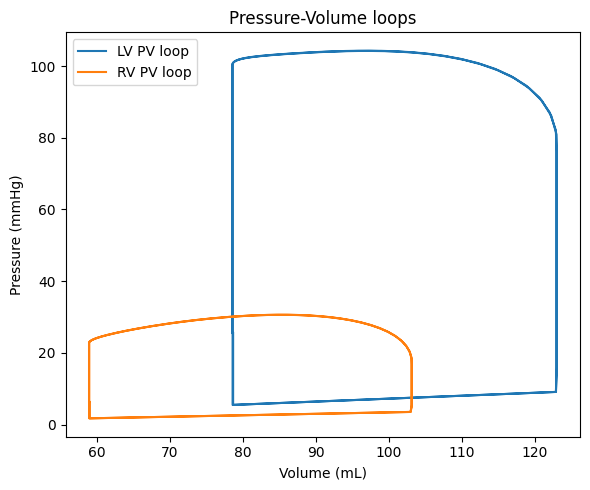

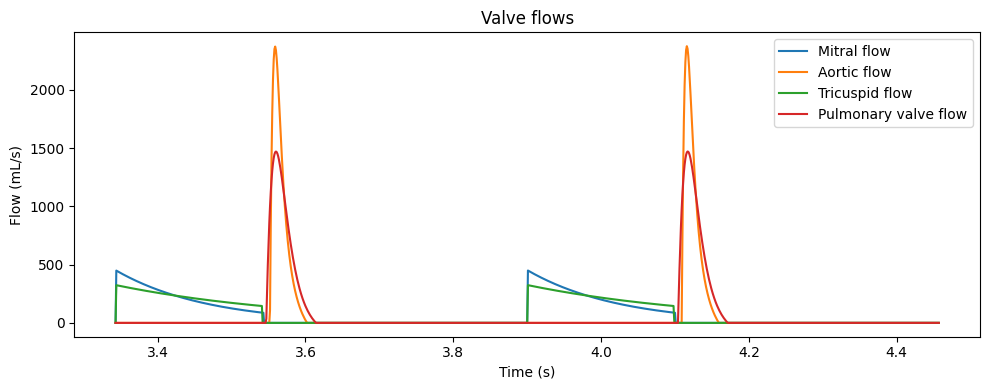


Approx LV metrics (final beat):
EDV = 122.96 mL
ESV = 78.57 mL
SV  = 44.39 mL
EF  = 36.10 %


In [7]:
# ============================================================
# Reduced Bio-Electro-Mechanical (Bio-MEM) Heart Model
# ------------------------------------------------------------
# Features:
#   1) Graph-based electrical conduction (SA -> AV -> His -> Purkinje -> myocardium)
#   2) Segmental activation for LV/RV
#   3) Time-varying elastance chamber mechanics
#   4) Simple systemic + pulmonary Windkessel circulation
#   5) Pressure-volume loops and activation plots
#
# This is a reduced-order research/prototyping model inspired by:
#   - Purkinje network driven activation timing
#   - PV loop / EDPVR / ESPVR-based chamber mechanics
# ============================================================

@dataclass
class Segment:
    name: str
    chamber: str          # "LV" or "RV"
    activation_delay: float = 0.0  # seconds


@dataclass
class HeartParams:
    # Rhythm
    heart_rate_bpm: float = 75.0
    n_beats: int = 8
    dt: float = 1e-3

    # Activation waveform
    tau_rise: float = 0.025
    tau_decay: float = 0.180
    electromech_delay: float = 0.030

    # LV mechanics
    E_lv_min: float = 0.08          # mmHg/mL
    E_lv_max: float = 2.20
    V0_lv: float = 10.0             # mL
    V_lv0: float = 140.0            # initial volume mL

    # RV mechanics
    E_rv_min: float = 0.04
    E_rv_max: float = 0.80
    V0_rv: float = 15.0
    V_rv0: float = 140.0

    # Atria / filling pressures (simple reduced-order forcing)
    P_la_base: float = 10.0         # mmHg
    P_la_amp: float = 3.0           # atrial kick amplitude
    P_ra_base: float = 5.0
    P_ra_amp: float = 2.0

    # Valve resistances
    R_mitral: float = 0.010         # mmHg*s/mL
    R_aortic: float = 0.008
    R_tricuspid: float = 0.010
    R_pulmonary_valve: float = 0.008

    # Systemic circulation Windkessel
    C_sys: float = 1.6              # mL/mmHg
    R_sys: float = 1.00             # mmHg*s/mL
    P_ao0: float = 80.0             # initial aortic pressure

    # Pulmonary circulation Windkessel
    C_pul: float = 6.0
    R_pul: float = 0.12
    P_pa0: float = 15.0             # initial pulmonary artery pressure

    # Venous return pressures (effective)
    P_ven_sys: float = 8.0
    P_ven_pul: float = 10.0

    # Optional passive nonlinearity
    alpha_passive_lv: float = 0.0020
    alpha_passive_rv: float = 0.0015


class ReducedBioMEMHeart:
    def __init__(self, params: HeartParams):
        self.p = params
        self.T = 60.0 / self.p.heart_rate_bpm

        self.segments = []
        self.graph = {}
        self._build_conduction_graph()
        self._compute_segment_delays()

    # --------------------------------------------------------
    # Electrical model: graph conduction
    # --------------------------------------------------------
    def _add_edge(self, a, b, delay_s):
        self.graph.setdefault(a, []).append((b, delay_s))

    def _build_conduction_graph(self):
        # Nodes:
        # SA -> AV -> HIS -> {LBB, RBB}
        # Then Purkinje terminals
        # Then ventricular segments
        self.graph = {}

        # Core conduction path
        self._add_edge("SA", "AV", 0.045)
        self._add_edge("AV", "HIS", 0.080)   # AV nodal delay
        self._add_edge("HIS", "LBB", 0.015)
        self._add_edge("HIS", "RBB", 0.015)

        # Purkinje terminals
        lv_terms = ["LV_P1", "LV_P2", "LV_P3", "LV_P4"]
        rv_terms = ["RV_P1", "RV_P2", "RV_P3"]

        for node in lv_terms:
            self._add_edge("LBB", node, 0.010)
        for node in rv_terms:
            self._add_edge("RBB", node, 0.010)

        # Myocardial segments
        lv_names = [
            "LV_septal", "LV_apex", "LV_lateral",
            "LV_anterior", "LV_posterior", "LV_base"
        ]
        rv_names = ["RV_freewall", "RV_apex", "RV_septal", "RV_base"]

        self.segments = [Segment(name=s, chamber="LV") for s in lv_names] + \
                        [Segment(name=s, chamber="RV") for s in rv_names]

        # Connect Purkinje terminals to segments
        lv_map = {
            "LV_P1": ["LV_septal", "LV_apex"],
            "LV_P2": ["LV_lateral"],
            "LV_P3": ["LV_anterior"],
            "LV_P4": ["LV_posterior", "LV_base"],
        }
        rv_map = {
            "RV_P1": ["RV_freewall"],
            "RV_P2": ["RV_apex", "RV_septal"],
            "RV_P3": ["RV_base"],
        }

        # Terminal-to-myocardium conduction delays
        for term, segs in lv_map.items():
            for s in segs:
                self._add_edge(term, s, 0.020)

        for term, segs in rv_map.items():
            for s in segs:
                self._add_edge(term, s, 0.018)

        # Slow myocardial spread between nearby segments
        local_links = [
            ("LV_septal", "LV_anterior", 0.018),
            ("LV_septal", "LV_posterior", 0.018),
            ("LV_apex", "LV_lateral", 0.020),
            ("LV_lateral", "LV_base", 0.020),
            ("RV_septal", "RV_freewall", 0.020),
            ("RV_apex", "RV_freewall", 0.018),
        ]
        for a, b, d in local_links:
            self._add_edge(a, b, d)
            self._add_edge(b, a, d)

    def _shortest_delays_from(self, source):
        dist = {node: np.inf for node in self.graph}
        # include terminal-only segment nodes not keys yet
        for edges in self.graph.values():
            for node, _ in edges:
                if node not in dist:
                    dist[node] = np.inf

        dist[source] = 0.0
        pq = [(0.0, source)]

        while pq:
            d, u = heapq.heappop(pq)
            if d > dist[u]:
                continue
            for v, w in self.graph.get(u, []):
                nd = d + w
                if nd < dist[v]:
                    dist[v] = nd
                    heapq.heappush(pq, (nd, v))
        return dist

    def _compute_segment_delays(self):
        dist = self._shortest_delays_from("SA")
        for seg in self.segments:
            seg.activation_delay = dist.get(seg.name, np.inf)

    # --------------------------------------------------------
    # Activation model
    # --------------------------------------------------------
    def beat_phase(self, t):
        return t % self.T

    def activation_kernel(self, phase, t_act):
        """
        Smooth pulse starting after t_act:
        a(t) = (1 - exp(-(t-t_act)/tau_rise)) * exp(-(t-t_act)/tau_decay), t > t_act
        """
        x = phase - t_act
        if np.isscalar(x):
            if x <= 0:
                return 0.0
            return (1.0 - np.exp(-x / self.p.tau_rise)) * np.exp(-x / self.p.tau_decay)
        out = np.zeros_like(x)
        mask = x > 0
        xm = x[mask]
        out[mask] = (1.0 - np.exp(-xm / self.p.tau_rise)) * np.exp(-xm / self.p.tau_decay)
        return out

    def segment_activation(self, t, seg: Segment):
        phase = self.beat_phase(t)
        t_act = seg.activation_delay + self.p.electromech_delay
        return self.activation_kernel(phase, t_act)

    def chamber_activation(self, t, chamber):
        vals = [self.segment_activation(t, s) for s in self.segments if s.chamber == chamber]
        vals = np.array(vals, dtype=float)
        if vals.max() <= 1e-12:
            return 0.0
        return vals.mean() / max(vals.max(), 1.0)

    # --------------------------------------------------------
    # Mechanics
    # --------------------------------------------------------
    def atrial_pressure_left(self, t):
        phase = self.beat_phase(t)
        atrial_center = 0.85 * self.T
        width = 0.08 * self.T
        atrial_kick = self.p.P_la_amp * np.exp(-0.5 * ((phase - atrial_center) / width) ** 2)
        return self.p.P_la_base + atrial_kick

    def atrial_pressure_right(self, t):
        phase = self.beat_phase(t)
        atrial_center = 0.85 * self.T
        width = 0.08 * self.T
        atrial_kick = self.p.P_ra_amp * np.exp(-0.5 * ((phase - atrial_center) / width) ** 2)
        return self.p.P_ra_base + atrial_kick

    def passive_pressure(self, V, V0, alpha):
        # Simple exponential passive stiffness
        dv = max(V - V0, 0.0)
        return alpha * (np.exp(0.035 * dv) - 1.0)

    def elastance(self, t, chamber):
        A = self.chamber_activation(t, chamber)
        if chamber == "LV":
            return self.p.E_lv_min + (self.p.E_lv_max - self.p.E_lv_min) * A
        elif chamber == "RV":
            return self.p.E_rv_min + (self.p.E_rv_max - self.p.E_rv_min) * A
        raise ValueError("Unknown chamber")

    def chamber_pressure(self, t, V, chamber):
        if chamber == "LV":
            E = self.elastance(t, "LV")
            return E * (V - self.p.V0_lv) + self.passive_pressure(V, self.p.V0_lv, self.p.alpha_passive_lv)
        elif chamber == "RV":
            E = self.elastance(t, "RV")
            return E * (V - self.p.V0_rv) + self.passive_pressure(V, self.p.V0_rv, self.p.alpha_passive_rv)
        raise ValueError("Unknown chamber")

    @staticmethod
    def valve_flow(P_up, P_down, R):
        return max((P_up - P_down) / R, 0.0)

    # --------------------------------------------------------
    # Time integration
    # --------------------------------------------------------
    def simulate(self):
        t_end = self.p.n_beats * self.T
        t = np.arange(0.0, t_end, self.p.dt)
        n = len(t)

        V_lv = np.zeros(n)
        V_rv = np.zeros(n)
        P_lv = np.zeros(n)
        P_rv = np.zeros(n)
        P_ao = np.zeros(n)
        P_pa = np.zeros(n)
        P_la = np.zeros(n)
        P_ra = np.zeros(n)

        Q_mv = np.zeros(n)
        Q_av = np.zeros(n)
        Q_tv = np.zeros(n)
        Q_pv = np.zeros(n)
        A_lv = np.zeros(n)
        A_rv = np.zeros(n)

        V_lv[0] = self.p.V_lv0
        V_rv[0] = self.p.V_rv0
        P_ao[0] = self.p.P_ao0
        P_pa[0] = self.p.P_pa0

        for k in range(n - 1):
            tk = t[k]

            # Current atrial pressures
            P_la[k] = self.atrial_pressure_left(tk)
            P_ra[k] = self.atrial_pressure_right(tk)

            # Chamber pressures
            P_lv[k] = self.chamber_pressure(tk, V_lv[k], "LV")
            P_rv[k] = self.chamber_pressure(tk, V_rv[k], "RV")

            # Activation
            A_lv[k] = self.chamber_activation(tk, "LV")
            A_rv[k] = self.chamber_activation(tk, "RV")

            # Valve flows
            Q_mv[k] = self.valve_flow(P_la[k], P_lv[k], self.p.R_mitral)
            Q_av[k] = self.valve_flow(P_lv[k], P_ao[k], self.p.R_aortic)

            Q_tv[k] = self.valve_flow(P_ra[k], P_rv[k], self.p.R_tricuspid)
            Q_pv[k] = self.valve_flow(P_rv[k], P_pa[k], self.p.R_pulmonary_valve)

            # Chamber volume dynamics
            dV_lv = Q_mv[k] - Q_av[k]
            dV_rv = Q_tv[k] - Q_pv[k]

            # Arterial / pulmonary pressures (2-element Windkessel)
            # inflow - runoff
            dP_ao = (Q_av[k] - (P_ao[k] - self.p.P_ven_sys) / self.p.R_sys) / self.p.C_sys
            dP_pa = (Q_pv[k] - (P_pa[k] - self.p.P_ven_pul) / self.p.R_pul) / self.p.C_pul

            V_lv[k + 1] = max(V_lv[k] + self.p.dt * dV_lv, self.p.V0_lv + 1e-3)
            V_rv[k + 1] = max(V_rv[k] + self.p.dt * dV_rv, self.p.V0_rv + 1e-3)
            P_ao[k + 1] = max(P_ao[k] + self.p.dt * dP_ao, 0.0)
            P_pa[k + 1] = max(P_pa[k] + self.p.dt * dP_pa, 0.0)

        # Final sample
        P_la[-1] = self.atrial_pressure_left(t[-1])
        P_ra[-1] = self.atrial_pressure_right(t[-1])
        P_lv[-1] = self.chamber_pressure(t[-1], V_lv[-1], "LV")
        P_rv[-1] = self.chamber_pressure(t[-1], V_rv[-1], "RV")
        A_lv[-1] = self.chamber_activation(t[-1], "LV")
        A_rv[-1] = self.chamber_activation(t[-1], "RV")
        Q_mv[-1] = self.valve_flow(P_la[-1], P_lv[-1], self.p.R_mitral)
        Q_av[-1] = self.valve_flow(P_lv[-1], P_ao[-1], self.p.R_aortic)
        Q_tv[-1] = self.valve_flow(P_ra[-1], P_rv[-1], self.p.R_tricuspid)
        Q_pv[-1] = self.valve_flow(P_rv[-1], P_pa[-1], self.p.R_pulmonary_valve)

        return {
            "t": t,
            "V_lv": V_lv, "P_lv": P_lv,
            "V_rv": V_rv, "P_rv": P_rv,
            "P_ao": P_ao, "P_pa": P_pa,
            "P_la": P_la, "P_ra": P_ra,
            "Q_mv": Q_mv, "Q_av": Q_av,
            "Q_tv": Q_tv, "Q_pv": Q_pv,
            "A_lv": A_lv, "A_rv": A_rv,
        }

    # --------------------------------------------------------
    # Utilities
    # --------------------------------------------------------
    def print_activation_table(self):
        print("\nSegment activation delays (s):")
        for s in sorted(self.segments, key=lambda x: x.activation_delay):
            print(f"{s.name:12s} | {s.chamber} | {s.activation_delay:.4f}")

    def plot_results(self, out, last_beats=2):
        t = out["t"]
        t0 = max(0.0, t[-1] - last_beats * self.T)
        idx = t >= t0

        # Hemodynamics
        plt.figure(figsize=(10, 4))
        plt.plot(t[idx], out["P_lv"][idx], label="LV pressure")
        plt.plot(t[idx], out["P_ao"][idx], label="Aortic pressure")
        plt.plot(t[idx], out["P_rv"][idx], label="RV pressure")
        plt.plot(t[idx], out["P_pa"][idx], label="Pulm. artery pressure")
        plt.xlabel("Time (s)")
        plt.ylabel("Pressure (mmHg)")
        plt.title("Pressures")
        plt.legend()
        plt.tight_layout()

        # Volumes
        plt.figure(figsize=(10, 4))
        plt.plot(t[idx], out["V_lv"][idx], label="LV volume")
        plt.plot(t[idx], out["V_rv"][idx], label="RV volume")
        plt.xlabel("Time (s)")
        plt.ylabel("Volume (mL)")
        plt.title("Ventricular volumes")
        plt.legend()
        plt.tight_layout()

        # Activations
        plt.figure(figsize=(10, 4))
        plt.plot(t[idx], out["A_lv"][idx], label="LV activation")
        plt.plot(t[idx], out["A_rv"][idx], label="RV activation")
        plt.xlabel("Time (s)")
        plt.ylabel("Normalized activation")
        plt.title("Bio-electromechanical activation")
        plt.legend()
        plt.tight_layout()

        # PV loops
        plt.figure(figsize=(6, 5))
        plt.plot(out["V_lv"][idx], out["P_lv"][idx], label="LV PV loop")
        plt.plot(out["V_rv"][idx], out["P_rv"][idx], label="RV PV loop")
        plt.xlabel("Volume (mL)")
        plt.ylabel("Pressure (mmHg)")
        plt.title("Pressure-Volume loops")
        plt.legend()
        plt.tight_layout()

        # Valve flows
        plt.figure(figsize=(10, 4))
        plt.plot(t[idx], out["Q_mv"][idx], label="Mitral flow")
        plt.plot(t[idx], out["Q_av"][idx], label="Aortic flow")
        plt.plot(t[idx], out["Q_tv"][idx], label="Tricuspid flow")
        plt.plot(t[idx], out["Q_pv"][idx], label="Pulmonary valve flow")
        plt.xlabel("Time (s)")
        plt.ylabel("Flow (mL/s)")
        plt.title("Valve flows")
        plt.legend()
        plt.tight_layout()

        plt.show()


if __name__ == "__main__":

    # ==============================
    # 1. Cargar datos reales ECG
    # ==============================
    # loader = DataLoader(ptb_path="ptb-diagnostic-ecg-database-1.0.0")
    # data = loader.load_ptb_record("patient001", "s0010_re")

    # loader = DataLoader(mit_path="mit-bih-arrhythmia-database-1.0.0")
    # data = loader.load_mit_record("100")

    # if data is None:
    #     print("Error cargando ECG")
    #     exit()

    # print("Datos extraídos:", data)

    # ==============================
    # 2. Ajustar modelo con datos reales
    # ==============================
    # params = HeartParams(
    #     heart_rate_bpm=data["hr_mean"],   # 🔥 aquí conectas ECG real
    #     n_beats=10,
    #     dt=1e-3
    # )

    loader = DataLoader(
        ptb_path="ptb-diagnostic-ecg-database-1.0.0",
        mit_path="mit-bih-arrhythmia-database-1.0.0",
    )

    # Iterar MIT-BIH completo
    for record_name, data in loader.iter_mit():
        params = HeartParams(heart_rate_bpm=data["hr_mean"])
        model = ReducedBioMEMHeart(params)
        out = model.simulate()

    # Iterar PTB completo
    for patient, record, data in loader.iter_ptb():
        params = HeartParams(heart_rate_bpm=data["hr_mean"])
        model = ReducedBioMEMHeart(params)
        out = model.simulate()

    # ==============================
    # 3. Simular BioMEM
    # ==============================
    model = ReducedBioMEMHeart(params)

    model.print_activation_table()

    out = model.simulate()

    model.plot_results(out, last_beats=2)

    # ==============================
    # 4. Métricas
    # ==============================
    T = model.T
    t = out["t"]
    idx = t >= (t[-1] - T)

    EDV_lv = out["V_lv"][idx].max()
    ESV_lv = out["V_lv"][idx].min()
    SV_lv = EDV_lv - ESV_lv
    EF_lv = 100.0 * SV_lv / EDV_lv

    print("\nApprox LV metrics (final beat):")
    print(f"EDV = {EDV_lv:.2f} mL")
    print(f"ESV = {ESV_lv:.2f} mL")
    print(f"SV  = {SV_lv:.2f} mL")
    print(f"EF  = {EF_lv:.2f} %")

# Heart VagusNerve2ECG GNN

In [29]:
# ============================================================
# Bio-MEM Heart as a Graph Neural Network in PyTorch
# ------------------------------------------------------------
# Input:
#   x: [B, T, input_dim]         e.g. vagus nerve stimulation time series
#
# Output:
#   ecg: [B, T, n_leads]         multi-channel ECG
#
# Graph:
#   Nodes represent conduction system + cardiac regions.
#   Edges represent conduction / coupling pathways.
#
# Notes:
#   - This is a learnable neural surrogate, not a full bidomain FEM model.
#   - It is designed to be trainable end-to-end from input -> ECG.
#   - You can later add supervision for node activation, pressure, PV loops, etc.
# ============================================================


# ------------------------------------------------------------
# Utilities
# ------------------------------------------------------------
def build_mlp(
    in_dim: int,
    hidden_dims: List[int],
    out_dim: int,
    activation=nn.SiLU,
    dropout: float = 0.0,
    final_activation: Optional[nn.Module] = None,
) -> nn.Sequential:
    layers = []
    prev = in_dim
    for h in hidden_dims:
        layers += [nn.Linear(prev, h), activation()]
        if dropout > 0:
            layers += [nn.Dropout(dropout)]
        prev = h
    layers += [nn.Linear(prev, out_dim)]
    if final_activation is not None:
        layers += [final_activation]
    return nn.Sequential(*layers)


def scatter_sum(src: torch.Tensor, index: torch.Tensor, dim_size: int) -> torch.Tensor:
    """
    src:   [B, E, H]
    index: [E] destination node indices
    out:   [B, N, H]
    """
    B, E, H = src.shape
    out = src.new_zeros(B, dim_size, H)
    out.index_add_(1, index, src.transpose(0, 1).transpose(0, 1))  # fallback not valid
    # Safer explicit loop on batch for vanilla PyTorch:
    for b in range(B):
        out[b].index_add_(0, index, src[b])
    return out


# ------------------------------------------------------------
# Graph specification
# ------------------------------------------------------------
@dataclass
class HeartGraphSpec:
    node_names: List[str]
    node_types: List[int]     # categorical
    chambers: List[int]       # 0 none, 1 LA, 2 RA, 3 LV, 4 RV, 5 Purkinje
    coords: torch.Tensor      # [N, 3]
    edge_index: torch.Tensor  # [2, E]
    edge_attr: torch.Tensor   # [E, edge_dim]


def build_default_heart_graph(device="cpu") -> HeartGraphSpec:
    """
    Small but structured heart graph:
      conduction nodes + regional atrial/ventricular nodes.
    """

    node_names = [
        "SA", "AV", "HIS", "LBB", "RBB",
        "LP1", "LP2", "LP3", "RP1", "RP2",
        "LA_ant", "LA_post", "RA_ant", "RA_post",
        "LV_septal", "LV_anterior", "LV_lateral", "LV_posterior", "LV_apex", "LV_base",
        "RV_septal", "RV_freewall", "RV_apex", "RV_base",
    ]

    # arbitrary categories:
    # 0 pacer, 1 relay, 2 bundle, 3 Purkinje, 4 atrial tissue, 5 ventricular tissue
    type_map = {
        "SA": 0, "AV": 1, "HIS": 2, "LBB": 2, "RBB": 2,
        "LP1": 3, "LP2": 3, "LP3": 3, "RP1": 3, "RP2": 3,
        "LA_ant": 4, "LA_post": 4, "RA_ant": 4, "RA_post": 4,
        "LV_septal": 5, "LV_anterior": 5, "LV_lateral": 5, "LV_posterior": 5, "LV_apex": 5, "LV_base": 5,
        "RV_septal": 5, "RV_freewall": 5, "RV_apex": 5, "RV_base": 5,
    }

    chamber_map = {
        "SA": 0, "AV": 0, "HIS": 0, "LBB": 5, "RBB": 5,
        "LP1": 5, "LP2": 5, "LP3": 5, "RP1": 5, "RP2": 5,
        "LA_ant": 1, "LA_post": 1, "RA_ant": 2, "RA_post": 2,
        "LV_septal": 3, "LV_anterior": 3, "LV_lateral": 3, "LV_posterior": 3, "LV_apex": 3, "LV_base": 3,
        "RV_septal": 4, "RV_freewall": 4, "RV_apex": 4, "RV_base": 4,
    }

    # crude anatomical coordinates for lead projection / spatial bias
    coords_dict = {
        "SA": (-0.2,  0.7,  0.2),
        "AV": (-0.1,  0.3,  0.0),
        "HIS": (0.0,  0.1,  0.0),
        "LBB": (-0.2, -0.1, -0.1),
        "RBB": ( 0.2, -0.1, -0.1),
        "LP1": (-0.35, -0.35, -0.1),
        "LP2": (-0.45, -0.45, -0.2),
        "LP3": (-0.25, -0.55, -0.25),
        "RP1": ( 0.35, -0.35, -0.1),
        "RP2": ( 0.25, -0.55, -0.2),
        "LA_ant": (-0.15, 0.55, 0.1),
        "LA_post": (-0.10, 0.45,-0.1),
        "RA_ant": ( 0.15, 0.55, 0.1),
        "RA_post": ( 0.10, 0.45,-0.1),
        "LV_septal": (-0.10,-0.30, 0.0),
        "LV_anterior": (-0.20,-0.35, 0.15),
        "LV_lateral": (-0.45,-0.35, 0.0),
        "LV_posterior": (-0.25,-0.40,-0.2),
        "LV_apex": (-0.20,-0.65,-0.15),
        "LV_base": (-0.15,-0.10, 0.0),
        "RV_septal": ( 0.08,-0.28, 0.0),
        "RV_freewall": ( 0.32,-0.35, 0.0),
        "RV_apex": ( 0.20,-0.58,-0.12),
        "RV_base": ( 0.12,-0.12, 0.0),
    }

    node_types = [type_map[n] for n in node_names]
    chambers = [chamber_map[n] for n in node_names]
    coords = torch.tensor([coords_dict[n] for n in node_names], dtype=torch.float32, device=device)

    name_to_idx = {n: i for i, n in enumerate(node_names)}

    def e(a, b, delay, weight, kind):
        # kind: 0 conduction, 1 tissue, 2 mech-coupling
        return (name_to_idx[a], name_to_idx[b], [delay, weight, kind])

    edges = []

    # Conduction backbone
    edges += [
        e("SA", "RA_ant", 0.020, 1.0, 0),
        e("SA", "LA_ant", 0.030, 0.9, 0),
        e("SA", "AV", 0.050, 1.0, 0),
        e("AV", "HIS", 0.080, 1.0, 0),
        e("HIS", "LBB", 0.015, 1.0, 0),
        e("HIS", "RBB", 0.015, 1.0, 0),
        e("LBB", "LP1", 0.010, 1.0, 0),
        e("LBB", "LP2", 0.012, 0.9, 0),
        e("LBB", "LP3", 0.014, 0.9, 0),
        e("RBB", "RP1", 0.010, 1.0, 0),
        e("RBB", "RP2", 0.013, 0.9, 0),
    ]

    # Purkinje to myocardium
    edges += [
        e("LP1", "LV_septal", 0.018, 1.0, 0),
        e("LP1", "LV_base", 0.020, 0.8, 0),
        e("LP2", "LV_lateral", 0.020, 1.0, 0),
        e("LP3", "LV_apex", 0.018, 1.0, 0),
        e("LP3", "LV_posterior", 0.020, 0.9, 0),
        e("RP1", "RV_septal", 0.018, 1.0, 0),
        e("RP1", "RV_base", 0.019, 0.8, 0),
        e("RP2", "RV_apex", 0.018, 1.0, 0),
        e("RP2", "RV_freewall", 0.020, 0.9, 0),
    ]

    # Tissue spread
    tissue_pairs = [
        ("LA_ant", "LA_post"),
        ("RA_ant", "RA_post"),
        ("LV_septal", "LV_anterior"),
        ("LV_septal", "LV_posterior"),
        ("LV_anterior", "LV_lateral"),
        ("LV_posterior", "LV_lateral"),
        ("LV_apex", "LV_lateral"),
        ("LV_apex", "LV_posterior"),
        ("LV_base", "LV_septal"),
        ("RV_septal", "RV_freewall"),
        ("RV_apex", "RV_freewall"),
        ("RV_base", "RV_septal"),
    ]
    for a, b in tissue_pairs:
        edges += [e(a, b, 0.025, 0.7, 1), e(b, a, 0.025, 0.7, 1)]

    # Mechanical coupling between ventricles / atria
    mech_pairs = [
        ("LV_septal", "RV_septal"),
        ("LV_base", "RV_base"),
        ("LA_post", "LV_base"),
        ("RA_post", "RV_base"),
    ]
    for a, b in mech_pairs:
        edges += [e(a, b, 0.040, 0.5, 2), e(b, a, 0.040, 0.5, 2)]

    src = torch.tensor([x[0] for x in edges], dtype=torch.long, device=device)
    dst = torch.tensor([x[1] for x in edges], dtype=torch.long, device=device)
    edge_attr = torch.tensor([x[2] for x in edges], dtype=torch.float32, device=device)
    edge_index = torch.stack([src, dst], dim=0)

    return HeartGraphSpec(
        node_names=node_names,
        node_types=node_types,
        chambers=chambers,
        coords=coords,
        edge_index=edge_index,
        edge_attr=edge_attr,
    )


# ------------------------------------------------------------
# Learned Graph Block
# ------------------------------------------------------------
class GraphMessagePassing(nn.Module):
    def __init__(self, node_dim: int, edge_dim: int, msg_dim: int, dropout: float = 0.0):
        super().__init__()
        self.msg_mlp = build_mlp(
            in_dim=2 * node_dim + edge_dim,
            hidden_dims=[msg_dim, msg_dim],
            out_dim=msg_dim,
            dropout=dropout,
        )
        self.upd_mlp = build_mlp(
            in_dim=node_dim + msg_dim,
            hidden_dims=[node_dim, node_dim],
            out_dim=node_dim,
            dropout=dropout,
        )
        self.norm = nn.LayerNorm(node_dim)

    def forward(
        self,
        h: torch.Tensor,              # [B, N, H]
        edge_index: torch.Tensor,     # [2, E]
        edge_attr: torch.Tensor,      # [E, D]
    ) -> torch.Tensor:
        src, dst = edge_index
        h_src = h[:, src, :]          # [B, E, H]
        h_dst = h[:, dst, :]          # [B, E, H]
        eattr = edge_attr.unsqueeze(0).expand(h.shape[0], -1, -1)  # [B, E, D]

        msg_in = torch.cat([h_src, h_dst, eattr], dim=-1)
        m = self.msg_mlp(msg_in)      # [B, E, M]
        agg = scatter_sum(m, dst, dim_size=h.shape[1])  # [B, N, M]

        upd = self.upd_mlp(torch.cat([h, agg], dim=-1))
        out = self.norm(h + upd)
        return out


class GraphGRUCell(nn.Module):
    """
    Graph recurrent update:
      h_t = GRUCell( local_input + messages, h_{t-1} )
    """
    def __init__(self, hidden_dim: int, edge_dim: int, msg_dim: int, dropout: float = 0.0):
        super().__init__()
        self.gmp = GraphMessagePassing(hidden_dim, edge_dim, msg_dim, dropout=dropout)
        self.in_proj = nn.Linear(hidden_dim, hidden_dim)
        self.gru = nn.GRUCell(hidden_dim, hidden_dim)
        self.norm = nn.LayerNorm(hidden_dim)

    def forward(self, h: torch.Tensor, local_drive: torch.Tensor, edge_index: torch.Tensor, edge_attr: torch.Tensor):
        """
        h:          [B, N, H]
        local_drive:[B, N, H]
        """
        m = self.gmp(h, edge_index, edge_attr)
        x = self.in_proj(local_drive) + m

        B, N, H = h.shape
        h_next = self.gru(
            x.reshape(B * N, H),
            h.reshape(B * N, H)
        ).reshape(B, N, H)
        h_next = self.norm(h_next)
        return h_next


# ------------------------------------------------------------
# ECG Decoder
# ------------------------------------------------------------
class ECGProjectionHead(nn.Module):
    """
    Decodes node states into distributed electrical source and projects to ECG leads.
    """
    def __init__(self, hidden_dim: int, n_leads: int, source_dim: int = 3):
        super().__init__()
        self.node_source = build_mlp(hidden_dim, [hidden_dim, hidden_dim], source_dim)
        self.global_refine = build_mlp(source_dim, [32, 32], source_dim)
        self.lead_proj = nn.Linear(source_dim, n_leads, bias=True)

    def forward(self, h: torch.Tensor, coords: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        """
        h:      [B, N, H]
        coords: [N, 3]

        Returns:
          ecg_t:     [B, n_leads]
          source_t:  [B, 3]
        """
        # Node electrical contribution
        src_node = self.node_source(h)                      # [B, N, 3]

        # Weight by spatial coordinates to mimic dipole-like aggregation
        coord = coords.unsqueeze(0).expand(h.shape[0], -1, -1)  # [B, N, 3]
        dipole = (src_node * coord).sum(dim=1)             # [B, 3]

        dipole = self.global_refine(dipole) + dipole
        ecg_t = self.lead_proj(dipole)
        return ecg_t, dipole


# ------------------------------------------------------------
# Full Model
# ------------------------------------------------------------
class BioMEMHeartGNN(nn.Module):
    def __init__(
        self,
        graph: HeartGraphSpec,
        input_dim: int = 4,
        hidden_dim: int = 128,
        node_emb_dim: int = 32,
        type_vocab: int = 6,
        chamber_vocab: int = 6,
        edge_dim: int = 3,
        msg_dim: int = 128,
        n_leads: int = 12,
        n_layers: int = 2,
        dropout: float = 0.0,
        teacher_forcing_aux: bool = False,
    ):
        super().__init__()
        self.graph = graph
        self.n_nodes = len(graph.node_names)
        self.hidden_dim = hidden_dim
        self.n_leads = n_leads
        self.teacher_forcing_aux = teacher_forcing_aux

        # Static node embeddings
        self.type_emb = nn.Embedding(type_vocab, node_emb_dim)
        self.chamber_emb = nn.Embedding(chamber_vocab, node_emb_dim)

        self.coord_proj = nn.Linear(3, node_emb_dim)

        self.node_init = build_mlp(
            in_dim=3 * node_emb_dim,
            hidden_dims=[hidden_dim, hidden_dim],
            out_dim=hidden_dim,
            dropout=dropout,
        )

        # Autonomic / vagal input encoder
        self.input_encoder = build_mlp(
            in_dim=input_dim,
            hidden_dims=[hidden_dim, hidden_dim],
            out_dim=hidden_dim,
            dropout=dropout,
        )

        # Node-specific autonomic gating
        self.autonomic_gate = build_mlp(
            in_dim=hidden_dim + hidden_dim,
            hidden_dims=[hidden_dim],
            out_dim=hidden_dim,
            dropout=dropout,
        )

        # Optional node-local physiological heads
        self.ion_head = build_mlp(hidden_dim, [hidden_dim], 1)      # membrane-like variable
        self.tension_head = build_mlp(hidden_dim, [hidden_dim], 1)  # active-tension-like variable
        self.phase_head = build_mlp(hidden_dim, [hidden_dim], 2)    # sin/cos phase-like latent

        self.cells = nn.ModuleList([
            GraphGRUCell(hidden_dim=hidden_dim, edge_dim=edge_dim, msg_dim=msg_dim, dropout=dropout)
            for _ in range(n_layers)
        ])

        self.ecg_head = ECGProjectionHead(hidden_dim=hidden_dim, n_leads=n_leads, source_dim=3)

        # Temporal output refinement
        self.temporal_refine = nn.GRU(
            input_size=n_leads + 3,
            hidden_size=hidden_dim,
            num_layers=1,
            batch_first=True,
            bidirectional=False,
        )
        self.out_head = build_mlp(hidden_dim, [hidden_dim], n_leads)

        # Register graph tensors as buffers
        self.register_buffer("node_types", torch.tensor(graph.node_types, dtype=torch.long))
        self.register_buffer("chambers", torch.tensor(graph.chambers, dtype=torch.long))
        self.register_buffer("coords", graph.coords.clone())
        self.register_buffer("edge_index", graph.edge_index.clone())
        self.register_buffer("edge_attr", graph.edge_attr.clone())

    def initial_node_state(self, batch_size: int) -> torch.Tensor:
        type_e = self.type_emb(self.node_types)      # [N, D]
        ch_e = self.chamber_emb(self.chambers)       # [N, D]
        co_e = self.coord_proj(self.coords)          # [N, D]

        node_static = torch.cat([type_e, ch_e, co_e], dim=-1)  # [N, 3D]
        h0 = self.node_init(node_static)             # [N, H]
        h0 = h0.unsqueeze(0).expand(batch_size, -1, -1).contiguous()
        return h0

    def autonomic_to_nodes(self, u_t: torch.Tensor, h: torch.Tensor) -> torch.Tensor:
        """
        u_t: [B, input_dim]
        h:   [B, N, H]
        returns local drive [B, N, H]
        """
        u = self.input_encoder(u_t)                          # [B, H]
        u_node = u.unsqueeze(1).expand(-1, self.n_nodes, -1)
        gate = torch.sigmoid(self.autonomic_gate(torch.cat([u_node, h], dim=-1)))
        local_drive = gate * u_node
        return local_drive

    def step(self, h: torch.Tensor, u_t: torch.Tensor):
        local_drive = self.autonomic_to_nodes(u_t, h)
        for cell in self.cells:
            h = cell(h, local_drive, self.edge_index, self.edge_attr)

        ecg_t_raw, source_t = self.ecg_head(h, self.coords)

        aux = {
            "vm": self.ion_head(h).squeeze(-1),             # [B, N]
            "tension": self.tension_head(h).squeeze(-1),    # [B, N]
            "phase": self.phase_head(h),                    # [B, N, 2]
            "source": source_t,                             # [B, 3]
        }
        return h, ecg_t_raw, aux

    def forward(
        self,
        x: torch.Tensor,                    # [B, T, input_dim]
        h0: Optional[torch.Tensor] = None,  # [B, N, H]
        return_aux: bool = True,
    ) -> Dict[str, torch.Tensor]:
        B, T, _ = x.shape
        h = self.initial_node_state(B) if h0 is None else h0

        ecg_raw_seq = []
        source_seq = []
        vm_seq = []
        tension_seq = []
        phase_seq = []

        for t in range(T):
            h, ecg_t, aux = self.step(h, x[:, t, :])
            ecg_raw_seq.append(ecg_t)
            source_seq.append(aux["source"])
            vm_seq.append(aux["vm"])
            tension_seq.append(aux["tension"])
            phase_seq.append(aux["phase"])

        ecg_raw = torch.stack(ecg_raw_seq, dim=1)       # [B, T, L]
        source = torch.stack(source_seq, dim=1)         # [B, T, 3]

        # Small temporal refinement on raw ECG + source
        z, _ = self.temporal_refine(torch.cat([ecg_raw, source], dim=-1))
        ecg = self.out_head(z) + ecg_raw                # residual refinement

        out = {"ecg": ecg}

        if return_aux:
            out.update({
                "source": source,
                "vm": torch.stack(vm_seq, dim=1),           # [B, T, N]
                "tension": torch.stack(tension_seq, dim=1), # [B, T, N]
                "phase": torch.stack(phase_seq, dim=1),     # [B, T, N, 2]
                "final_state": h,
            })

        return out


# ------------------------------------------------------------
# Losses
# ------------------------------------------------------------
class BioMEMLoss(nn.Module):
    def __init__(
        self,
        ecg_weight: float = 1.0,
        smooth_weight: float = 0.05,
        phys_weight: float = 0.05,
        source_weight: float = 0.01,
    ):
        super().__init__()
        self.ecg_weight = ecg_weight
        self.smooth_weight = smooth_weight
        self.phys_weight = phys_weight
        self.source_weight = source_weight

    def temporal_smoothness(self, y: torch.Tensor) -> torch.Tensor:
        # y: [B, T, C]
        dy = y[:, 1:, :] - y[:, :-1, :]
        return (dy ** 2).mean()

    def physiological_regularization(self, aux: Dict[str, torch.Tensor]) -> torch.Tensor:
        reg = 0.0

        # membrane-like state should not explode
        vm = aux["vm"]
        reg = reg + 0.1 * (vm ** 2).mean()

        # tension should remain reasonable
        tension = aux["tension"]
        reg = reg + 0.1 * F.relu(tension.abs() - 5.0).mean()

        # source smoothness
        source = aux["source"]
        dsrc = source[:, 1:, :] - source[:, :-1, :]
        reg = reg + 0.2 * (dsrc ** 2).mean()

        return reg

    def forward(self, pred: Dict[str, torch.Tensor], target_ecg: torch.Tensor) -> Dict[str, torch.Tensor]:
        ecg = pred["ecg"]

        l_ecg = F.mse_loss(ecg, target_ecg)
        l_smooth = self.temporal_smoothness(ecg)
        l_phys = self.physiological_regularization(pred)
        l_source = (pred["source"] ** 2).mean()

        total = (
            self.ecg_weight * l_ecg
            + self.smooth_weight * l_smooth
            + self.phys_weight * l_phys
            + self.source_weight * l_source
        )

        return {
            "loss": total,
            "ecg_mse": l_ecg,
            "smooth": l_smooth,
            "phys": l_phys,
            "source_reg": l_source,
        }


class ECGRealDataset(torch.utils.data.Dataset):
    def __init__(self, records, T=500, n_leads=1):
        """
        records: lista de dicts con:
            {
              "ecg": np.array,
              "fs": sampling_rate
            }
        """
        self.samples = []
        self.T = T
        self.n_leads = n_leads

        for rec in records:
            signal = rec["ecg"]

            # Normalizar
            signal = (signal - np.mean(signal)) / np.std(signal)

            # Sliding window
            for i in range(0, len(signal) - T, T):
                window = signal[i:i+T]

                # Input (puedes cambiar esto luego)
                x = np.zeros((T, 4))
                x[:, 0] = window  # usar ECG como entrada temporal

                # Target ECG (multi-lead fake si solo hay 1)
                y = np.repeat(window[:, None], n_leads, axis=1)

                self.samples.append((x, y))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        x, y = self.samples[idx]
        return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)


# ------------------------------------------------------------
# Training loop
# ------------------------------------------------------------
def train_one_epoch(model, loader, optimizer, criterion, device="cpu"):
    model.train()
    meters = {"loss": 0.0, "ecg_mse": 0.0, "smooth": 0.0, "phys": 0.0, "source_reg": 0.0}
    n = 0

    for x, y in loader:
        if x is None:
            continue

        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad()
        pred = model(x, return_aux=True)
        loss_dict = criterion(pred, y)
        loss_dict["loss"].backward()
        optimizer.step()

        bs = x.shape[0]
        n += bs
        for k in meters:
            meters[k] += loss_dict[k].item() * bs

    for k in meters:
        meters[k] /= max(n, 1)
    return meters


@torch.no_grad()
def evaluate(model, loader, criterion, device="cpu"):
    model.eval()
    meters = {"loss": 0.0, "ecg_mse": 0.0, "smooth": 0.0, "phys": 0.0, "source_reg": 0.0}
    n = 0

    for x, y in loader:
        if x is None:
            continue
        x = x.to(device)
        y = y.to(device)

        pred = model(x, return_aux=True)
        loss_dict = criterion(pred, y)

        bs = x.shape[0]
        n += bs
        for k in meters:
            meters[k] += loss_dict[k].item() * bs

    for k in meters:
        meters[k] /= max(n, 1)
    return meters


# ------------------------------------------------------------
# Example run
# ------------------------------------------------------------
if __name__ == "__main__":
    device = "cuda" if torch.cuda.is_available() else "cpu"

    graph = build_default_heart_graph(device=device)
    model = BioMEMHeartGNN(
        graph=graph,
        input_dim=5,  # ← cambiado de 4 a 5
        hidden_dim=128,
        node_emb_dim=32,
        msg_dim=128,
        n_leads=12,
        n_layers=2,
        dropout=0.05,
    ).to(device)

    # ── Dataset ──────────────────────────────────────────
    dataset = RealECGDataset(root_dir=".", T=500)
    n_train = int(0.8 * len(dataset))
    n_val   = len(dataset) - n_train
    train_ds, val_ds = torch.utils.data.random_split(
        dataset, [n_train, n_val],
        generator=torch.Generator().manual_seed(42),
    )

    # ── safe_collate va AQUÍ, justo antes de los loaders ─
    def safe_collate(batch):
        batch = [b for b in batch if b is not None]
        if not batch:
            return None
        return torch.utils.data.dataloader.default_collate(batch)

    train_loader = torch.utils.data.DataLoader(
        train_ds, batch_size=8, shuffle=True,
        collate_fn=safe_collate,
        num_workers=0,          # ← cambiar de 2 a 0
        pin_memory=False,       # ← False también, pin_memory requiere workers > 0
    )
    val_loader = torch.utils.data.DataLoader(
        val_ds, batch_size=8, shuffle=False,
        collate_fn=safe_collate,
        num_workers=0,          # ← cambiar de 2 a 0
        pin_memory=False,
    )

    # ... resto del código (criterion, optimizer, loop) ...

    criterion = BioMEMLoss(
        ecg_weight=1.0,
        smooth_weight=0.02,
        phys_weight=0.02,
        source_weight=0.005,
    )
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-5)

    for epoch in range(1, 11):
        tr = train_one_epoch(model, train_loader, optimizer, criterion, device=device)
        va = evaluate(model, val_loader, criterion, device=device)
        print(
            f"Epoch {epoch:03d} | "
            f"Train Loss={tr['loss']:.4f} ECG={tr['ecg_mse']:.4f} | "
            f"Val Loss={va['loss']:.4f} ECG={va['ecg_mse']:.4f}"
        )

    # Example inference
    x, y = val_ds[0]
    x = x.unsqueeze(0).to(device)
    out = model(x, return_aux=True)
    print("Pred ECG shape:", out["ecg"].shape)       # [1, T, 12]
    print("Node Vm shape:", out["vm"].shape)         # [1, T, N] 
    print("Node tension shape:", out["tension"].shape)

✅ Total records encontrados: 597
Epoch 001 | Train Loss=1.1070 ECG=1.1061 | Val Loss=1.0763 ECG=1.0754
Epoch 002 | Train Loss=1.0937 ECG=1.0928 | Val Loss=1.0844 ECG=1.0834
Epoch 003 | Train Loss=1.0965 ECG=1.0957 | Val Loss=1.0753 ECG=1.0745
Epoch 004 | Train Loss=1.0950 ECG=1.0940 | Val Loss=1.0723 ECG=1.0715
Epoch 005 | Train Loss=1.0918 ECG=1.0911 | Val Loss=1.0689 ECG=1.0677
Epoch 006 | Train Loss=1.0936 ECG=1.0929 | Val Loss=1.0704 ECG=1.0692
Epoch 007 | Train Loss=1.0909 ECG=1.0901 | Val Loss=1.0670 ECG=1.0662
Epoch 008 | Train Loss=1.0900 ECG=1.0892 | Val Loss=1.0800 ECG=1.0784
Epoch 009 | Train Loss=1.0817 ECG=1.0807 | Val Loss=1.0501 ECG=1.0495
Epoch 010 | Train Loss=1.0436 ECG=1.0427 | Val Loss=1.0221 ECG=1.0208
Pred ECG shape: torch.Size([1, 500, 12])
Node Vm shape: torch.Size([1, 500, 24])
Node tension shape: torch.Size([1, 500, 24])


# Heart Ox2ECG GNN

In [27]:

# ============================================================
# Bio-MEM Heart GNN: Oximetry/PPG -> Multi-channel ECG
# ------------------------------------------------------------
# Input:
#   x: [B, T, input_dim]
#      e.g. pulse oximetry / PPG features
#
# Output:
#   ecg: [B, T, n_leads]
#
# Notes:
#   - Pure PyTorch, no PyG dependency.
#   - Graph nodes represent conduction + myocardial regions.
#   - Input is now oximetry/PPG rather than vagal drive.
#   - Suitable as a structured surrogate for PPG-to-ECG mapping.
# ============================================================


# ------------------------------------------------------------
# Utilities
# ------------------------------------------------------------
def build_mlp(
    in_dim: int,
    hidden_dims: List[int],
    out_dim: int,
    activation=nn.SiLU,
    dropout: float = 0.0,
    final_activation: Optional[nn.Module] = None,
) -> nn.Sequential:
    layers = []
    prev = in_dim
    for h in hidden_dims:
        layers += [nn.Linear(prev, h), activation()]
        if dropout > 0:
            layers += [nn.Dropout(dropout)]
        prev = h
    layers += [nn.Linear(prev, out_dim)]
    if final_activation is not None:
        layers += [final_activation]
    return nn.Sequential(*layers)


def scatter_sum(src: torch.Tensor, index: torch.Tensor, dim_size: int) -> torch.Tensor:
    """
    src:   [B, E, H]
    index: [E]
    out:   [B, N, H]
    """
    B, E, H = src.shape
    out = src.new_zeros(B, dim_size, H)
    for b in range(B):
        out[b].index_add_(0, index, src[b])
    return out


# ------------------------------------------------------------
# Graph specification
# ------------------------------------------------------------
@dataclass
class HeartGraphSpec:
    node_names: List[str]
    node_types: List[int]
    chambers: List[int]
    coords: torch.Tensor
    edge_index: torch.Tensor
    edge_attr: torch.Tensor


def build_default_heart_graph(device="cpu") -> HeartGraphSpec:
    node_names = [
        "SA", "AV", "HIS", "LBB", "RBB",
        "LP1", "LP2", "LP3", "RP1", "RP2",
        "LA_ant", "LA_post", "RA_ant", "RA_post",
        "LV_septal", "LV_anterior", "LV_lateral", "LV_posterior", "LV_apex", "LV_base",
        "RV_septal", "RV_freewall", "RV_apex", "RV_base",
    ]

    type_map = {
        "SA": 0, "AV": 1, "HIS": 2, "LBB": 2, "RBB": 2,
        "LP1": 3, "LP2": 3, "LP3": 3, "RP1": 3, "RP2": 3,
        "LA_ant": 4, "LA_post": 4, "RA_ant": 4, "RA_post": 4,
        "LV_septal": 5, "LV_anterior": 5, "LV_lateral": 5, "LV_posterior": 5, "LV_apex": 5, "LV_base": 5,
        "RV_septal": 5, "RV_freewall": 5, "RV_apex": 5, "RV_base": 5,
    }

    chamber_map = {
        "SA": 0, "AV": 0, "HIS": 0, "LBB": 5, "RBB": 5,
        "LP1": 5, "LP2": 5, "LP3": 5, "RP1": 5, "RP2": 5,
        "LA_ant": 1, "LA_post": 1, "RA_ant": 2, "RA_post": 2,
        "LV_septal": 3, "LV_anterior": 3, "LV_lateral": 3, "LV_posterior": 3, "LV_apex": 3, "LV_base": 3,
        "RV_septal": 4, "RV_freewall": 4, "RV_apex": 4, "RV_base": 4,
    }

    coords_dict = {
        "SA": (-0.2,  0.7,  0.2),
        "AV": (-0.1,  0.3,  0.0),
        "HIS": (0.0,  0.1,  0.0),
        "LBB": (-0.2, -0.1, -0.1),
        "RBB": ( 0.2, -0.1, -0.1),
        "LP1": (-0.35, -0.35, -0.1),
        "LP2": (-0.45, -0.45, -0.2),
        "LP3": (-0.25, -0.55, -0.25),
        "RP1": ( 0.35, -0.35, -0.1),
        "RP2": ( 0.25, -0.55, -0.2),
        "LA_ant": (-0.15, 0.55, 0.1),
        "LA_post": (-0.10, 0.45,-0.1),
        "RA_ant": ( 0.15, 0.55, 0.1),
        "RA_post": ( 0.10, 0.45,-0.1),
        "LV_septal": (-0.10,-0.30, 0.0),
        "LV_anterior": (-0.20,-0.35, 0.15),
        "LV_lateral": (-0.45,-0.35, 0.0),
        "LV_posterior": (-0.25,-0.40,-0.2),
        "LV_apex": (-0.20,-0.65,-0.15),
        "LV_base": (-0.15,-0.10, 0.0),
        "RV_septal": ( 0.08,-0.28, 0.0),
        "RV_freewall": ( 0.32,-0.35, 0.0),
        "RV_apex": ( 0.20,-0.58,-0.12),
        "RV_base": ( 0.12,-0.12, 0.0),
    }

    node_types = [type_map[n] for n in node_names]
    chambers = [chamber_map[n] for n in node_names]
    coords = torch.tensor([coords_dict[n] for n in node_names], dtype=torch.float32, device=device)

    name_to_idx = {n: i for i, n in enumerate(node_names)}

    def e(a, b, delay, weight, kind):
        return (name_to_idx[a], name_to_idx[b], [delay, weight, kind])

    edges = []
    edges += [
        e("SA", "RA_ant", 0.020, 1.0, 0),
        e("SA", "LA_ant", 0.030, 0.9, 0),
        e("SA", "AV", 0.050, 1.0, 0),
        e("AV", "HIS", 0.080, 1.0, 0),
        e("HIS", "LBB", 0.015, 1.0, 0),
        e("HIS", "RBB", 0.015, 1.0, 0),
        e("LBB", "LP1", 0.010, 1.0, 0),
        e("LBB", "LP2", 0.012, 0.9, 0),
        e("LBB", "LP3", 0.014, 0.9, 0),
        e("RBB", "RP1", 0.010, 1.0, 0),
        e("RBB", "RP2", 0.013, 0.9, 0),
    ]

    edges += [
        e("LP1", "LV_septal", 0.018, 1.0, 0),
        e("LP1", "LV_base", 0.020, 0.8, 0),
        e("LP2", "LV_lateral", 0.020, 1.0, 0),
        e("LP3", "LV_apex", 0.018, 1.0, 0),
        e("LP3", "LV_posterior", 0.020, 0.9, 0),
        e("RP1", "RV_septal", 0.018, 1.0, 0),
        e("RP1", "RV_base", 0.019, 0.8, 0),
        e("RP2", "RV_apex", 0.018, 1.0, 0),
        e("RP2", "RV_freewall", 0.020, 0.9, 0),
    ]

    tissue_pairs = [
        ("LA_ant", "LA_post"),
        ("RA_ant", "RA_post"),
        ("LV_septal", "LV_anterior"),
        ("LV_septal", "LV_posterior"),
        ("LV_anterior", "LV_lateral"),
        ("LV_posterior", "LV_lateral"),
        ("LV_apex", "LV_lateral"),
        ("LV_apex", "LV_posterior"),
        ("LV_base", "LV_septal"),
        ("RV_septal", "RV_freewall"),
        ("RV_apex", "RV_freewall"),
        ("RV_base", "RV_septal"),
    ]
    for a, b in tissue_pairs:
        edges += [e(a, b, 0.025, 0.7, 1), e(b, a, 0.025, 0.7, 1)]

    mech_pairs = [
        ("LV_septal", "RV_septal"),
        ("LV_base", "RV_base"),
        ("LA_post", "LV_base"),
        ("RA_post", "RV_base"),
    ]
    for a, b in mech_pairs:
        edges += [e(a, b, 0.040, 0.5, 2), e(b, a, 0.040, 0.5, 2)]

    src = torch.tensor([x[0] for x in edges], dtype=torch.long, device=device)
    dst = torch.tensor([x[1] for x in edges], dtype=torch.long, device=device)
    edge_attr = torch.tensor([x[2] for x in edges], dtype=torch.float32, device=device)
    edge_index = torch.stack([src, dst], dim=0)

    return HeartGraphSpec(
        node_names=node_names,
        node_types=node_types,
        chambers=chambers,
        coords=coords,
        edge_index=edge_index,
        edge_attr=edge_attr,
    )


# ------------------------------------------------------------
# GNN blocks
# ------------------------------------------------------------
class GraphMessagePassing(nn.Module):
    def __init__(self, node_dim: int, edge_dim: int, msg_dim: int, dropout: float = 0.0):
        super().__init__()
        self.msg_mlp = build_mlp(
            in_dim=2 * node_dim + edge_dim,
            hidden_dims=[msg_dim, msg_dim],
            out_dim=msg_dim,
            dropout=dropout,
        )
        self.upd_mlp = build_mlp(
            in_dim=node_dim + msg_dim,
            hidden_dims=[node_dim, node_dim],
            out_dim=node_dim,
            dropout=dropout,
        )
        self.norm = nn.LayerNorm(node_dim)

    def forward(self, h: torch.Tensor, edge_index: torch.Tensor, edge_attr: torch.Tensor) -> torch.Tensor:
        src, dst = edge_index
        h_src = h[:, src, :]
        h_dst = h[:, dst, :]
        eattr = edge_attr.unsqueeze(0).expand(h.shape[0], -1, -1)

        msg_in = torch.cat([h_src, h_dst, eattr], dim=-1)
        m = self.msg_mlp(msg_in)
        agg = scatter_sum(m, dst, dim_size=h.shape[1])

        upd = self.upd_mlp(torch.cat([h, agg], dim=-1))
        out = self.norm(h + upd)
        return out


class GraphGRUCell(nn.Module):
    def __init__(self, hidden_dim: int, edge_dim: int, msg_dim: int, dropout: float = 0.0):
        super().__init__()
        self.gmp = GraphMessagePassing(hidden_dim, edge_dim, msg_dim, dropout=dropout)
        self.in_proj = nn.Linear(hidden_dim, hidden_dim)
        self.gru = nn.GRUCell(hidden_dim, hidden_dim)
        self.norm = nn.LayerNorm(hidden_dim)

    def forward(self, h: torch.Tensor, local_drive: torch.Tensor, edge_index: torch.Tensor, edge_attr: torch.Tensor):
        m = self.gmp(h, edge_index, edge_attr)
        x = self.in_proj(local_drive) + m

        B, N, H = h.shape
        h_next = self.gru(
            x.reshape(B * N, H),
            h.reshape(B * N, H)
        ).reshape(B, N, H)
        return self.norm(h_next)


# ------------------------------------------------------------
# ECG decoder
# ------------------------------------------------------------
class ECGProjectionHead(nn.Module):
    def __init__(self, hidden_dim: int, n_leads: int, source_dim: int = 3):
        super().__init__()
        self.node_source = build_mlp(hidden_dim, [hidden_dim, hidden_dim], source_dim)
        self.global_refine = build_mlp(source_dim, [32, 32], source_dim)
        self.lead_proj = nn.Linear(source_dim, n_leads, bias=True)

    def forward(self, h: torch.Tensor, coords: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        src_node = self.node_source(h)  # [B, N, 3]
        coord = coords.unsqueeze(0).expand(h.shape[0], -1, -1)
        dipole = (src_node * coord).sum(dim=1)  # [B, 3]
        dipole = self.global_refine(dipole) + dipole
        ecg_t = self.lead_proj(dipole)
        return ecg_t, dipole


# ------------------------------------------------------------
# Oximetry encoder
# ------------------------------------------------------------
class OximetryEncoder(nn.Module):
    """
    Encodes pulse oximetry / PPG waveform into latent features.

    Example input channels:
      1) raw PPG
      2) first derivative
      3) second derivative
      4) SpO2
      5) perfusion index
    """
    def __init__(self, input_dim: int, hidden_dim: int):
        super().__init__()
        self.conv1 = nn.Conv1d(input_dim, hidden_dim // 2, kernel_size=7, padding=3)
        self.conv2 = nn.Conv1d(hidden_dim // 2, hidden_dim, kernel_size=5, padding=2)
        self.norm1 = nn.BatchNorm1d(hidden_dim // 2)
        self.norm2 = nn.BatchNorm1d(hidden_dim)
        self.proj = nn.Linear(hidden_dim, hidden_dim)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: [B, T, C]
        z = x.transpose(1, 2)  # [B, C, T]
        z = F.silu(self.norm1(self.conv1(z)))
        z = F.silu(self.norm2(self.conv2(z)))
        z = z.transpose(1, 2)  # [B, T, H]
        z = self.proj(z)
        return z


# ------------------------------------------------------------
# Full model: Oximetry -> ECG
# ------------------------------------------------------------
class BioMEMOximetryToECG(nn.Module):
    def __init__(
        self,
        graph: HeartGraphSpec,
        input_dim: int = 5,
        hidden_dim: int = 128,
        node_emb_dim: int = 32,
        type_vocab: int = 6,
        chamber_vocab: int = 6,
        edge_dim: int = 3,
        msg_dim: int = 128,
        n_leads: int = 12,
        n_layers: int = 2,
        dropout: float = 0.0,
    ):
        super().__init__()
        self.graph = graph
        self.n_nodes = len(graph.node_names)
        self.hidden_dim = hidden_dim
        self.n_leads = n_leads

        self.type_emb = nn.Embedding(type_vocab, node_emb_dim)
        self.chamber_emb = nn.Embedding(chamber_vocab, node_emb_dim)
        self.coord_proj = nn.Linear(3, node_emb_dim)

        self.node_init = build_mlp(
            in_dim=3 * node_emb_dim,
            hidden_dims=[hidden_dim, hidden_dim],
            out_dim=hidden_dim,
            dropout=dropout,
        )

        self.oximetry_encoder = OximetryEncoder(input_dim=input_dim, hidden_dim=hidden_dim)

        self.obs_to_nodes = build_mlp(
            in_dim=2 * hidden_dim,
            hidden_dims=[hidden_dim],
            out_dim=hidden_dim,
            dropout=dropout,
        )

        self.obs_gate = build_mlp(
            in_dim=2 * hidden_dim,
            hidden_dims=[hidden_dim],
            out_dim=hidden_dim,
            dropout=dropout,
        )

        self.cells = nn.ModuleList([
            GraphGRUCell(hidden_dim=hidden_dim, edge_dim=edge_dim, msg_dim=msg_dim, dropout=dropout)
            for _ in range(n_layers)
        ])

        self.ion_head = build_mlp(hidden_dim, [hidden_dim], 1)
        self.tension_head = build_mlp(hidden_dim, [hidden_dim], 1)
        self.phase_head = build_mlp(hidden_dim, [hidden_dim], 2)

        self.ecg_head = ECGProjectionHead(hidden_dim=hidden_dim, n_leads=n_leads, source_dim=3)

        self.temporal_refine = nn.GRU(
            input_size=n_leads + 3,
            hidden_size=hidden_dim,
            num_layers=1,
            batch_first=True,
        )
        self.out_head = build_mlp(hidden_dim, [hidden_dim], n_leads)

        self.register_buffer("node_types", torch.tensor(graph.node_types, dtype=torch.long))
        self.register_buffer("chambers", torch.tensor(graph.chambers, dtype=torch.long))
        self.register_buffer("coords", graph.coords.clone())
        self.register_buffer("edge_index", graph.edge_index.clone())
        self.register_buffer("edge_attr", graph.edge_attr.clone())

    def initial_node_state(self, batch_size: int) -> torch.Tensor:
        type_e = self.type_emb(self.node_types)
        ch_e = self.chamber_emb(self.chambers)
        co_e = self.coord_proj(self.coords)

        node_static = torch.cat([type_e, ch_e, co_e], dim=-1)
        h0 = self.node_init(node_static)
        return h0.unsqueeze(0).expand(batch_size, -1, -1).contiguous()

    def observation_to_nodes(self, obs_t: torch.Tensor, h: torch.Tensor) -> torch.Tensor:
        """
        obs_t: [B, H] encoded oximetry at time t
        h:     [B, N, H]
        """
        obs_node = obs_t.unsqueeze(1).expand(-1, self.n_nodes, -1)
        fused = torch.cat([obs_node, h], dim=-1)
        gate = torch.sigmoid(self.obs_gate(fused))
        local_drive = gate * self.obs_to_nodes(fused)
        return local_drive

    def step(self, h: torch.Tensor, obs_t: torch.Tensor):
        local_drive = self.observation_to_nodes(obs_t, h)

        for cell in self.cells:
            h = cell(h, local_drive, self.edge_index, self.edge_attr)

        ecg_t_raw, source_t = self.ecg_head(h, self.coords)

        aux = {
            "vm": self.ion_head(h).squeeze(-1),
            "tension": self.tension_head(h).squeeze(-1),
            "phase": self.phase_head(h),
            "source": source_t,
        }
        return h, ecg_t_raw, aux

    def forward(
        self,
        x: torch.Tensor,                    # [B, T, input_dim]
        h0: Optional[torch.Tensor] = None,
        return_aux: bool = True,
    ) -> Dict[str, torch.Tensor]:
        B, T, _ = x.shape
        h = self.initial_node_state(B) if h0 is None else h0

        obs_seq = self.oximetry_encoder(x)  # [B, T, H]

        ecg_raw_seq = []
        source_seq = []
        vm_seq = []
        tension_seq = []
        phase_seq = []

        for t in range(T):
            h, ecg_t, aux = self.step(h, obs_seq[:, t, :])
            ecg_raw_seq.append(ecg_t)
            source_seq.append(aux["source"])
            vm_seq.append(aux["vm"])
            tension_seq.append(aux["tension"])
            phase_seq.append(aux["phase"])

        ecg_raw = torch.stack(ecg_raw_seq, dim=1)
        source = torch.stack(source_seq, dim=1)

        z, _ = self.temporal_refine(torch.cat([ecg_raw, source], dim=-1))
        ecg = self.out_head(z) + ecg_raw

        out = {"ecg": ecg}

        if return_aux:
            out.update({
                "source": source,
                "vm": torch.stack(vm_seq, dim=1),
                "tension": torch.stack(tension_seq, dim=1),
                "phase": torch.stack(phase_seq, dim=1),
                "final_state": h,
            })

        return out


# ------------------------------------------------------------
# Loss
# ------------------------------------------------------------
class OximetryToECGLoss(nn.Module):
    def __init__(
        self,
        ecg_weight: float = 1.0,
        smooth_weight: float = 0.05,
        phys_weight: float = 0.05,
        source_weight: float = 0.01,
    ):
        super().__init__()
        self.ecg_weight = ecg_weight
        self.smooth_weight = smooth_weight
        self.phys_weight = phys_weight
        self.source_weight = source_weight

    def temporal_smoothness(self, y: torch.Tensor) -> torch.Tensor:
        dy = y[:, 1:, :] - y[:, :-1, :]
        return (dy ** 2).mean()

    def physiological_regularization(self, pred: Dict[str, torch.Tensor]) -> torch.Tensor:
        reg = 0.0
        reg += 0.1 * (pred["vm"] ** 2).mean()
        reg += 0.1 * F.relu(pred["tension"].abs() - 5.0).mean()
        dsrc = pred["source"][:, 1:, :] - pred["source"][:, :-1, :]
        reg += 0.2 * (dsrc ** 2).mean()
        return reg

    def forward(self, pred: Dict[str, torch.Tensor], target_ecg: torch.Tensor) -> Dict[str, torch.Tensor]:
        ecg = pred["ecg"]

        l_ecg = F.mse_loss(ecg, target_ecg)
        l_smooth = self.temporal_smoothness(ecg)
        l_phys = self.physiological_regularization(pred)
        l_source = (pred["source"] ** 2).mean()

        total = (
            self.ecg_weight * l_ecg
            + self.smooth_weight * l_smooth
            + self.phys_weight * l_phys
            + self.source_weight * l_source
        )

        return {
            "loss": total,
            "ecg_mse": l_ecg,
            "smooth": l_smooth,
            "phys": l_phys,
            "source_reg": l_source,
        }


# ------------------------------------------------------------
# Example synthetic dataset
# ------------------------------------------------------------
class DummyOximetryToECGDataset(torch.utils.data.Dataset):
    """
    Synthetic placeholder.

    Input channels example:
      0 raw PPG
      1 dPPG/dt
      2 d2PPG/dt2
      3 SpO2
      4 perfusion index

    Target:
      12-lead ECG
    """
    def __init__(self, n_samples=256, T=500, input_dim=5, n_leads=12):
        self.n_samples = n_samples
        self.T = T
        self.input_dim = input_dim
        self.n_leads = n_leads

    def __len__(self):
        return self.n_samples

    def __getitem__(self, idx):
        t = torch.linspace(0, 5, self.T)

        hr = 1.15 + 0.15 * torch.rand(1).item()
        ppg = 0.7 * torch.sin(2 * math.pi * hr * t) \
              + 0.2 * torch.sin(2 * math.pi * 2 * hr * t + 0.3)
        ppg += 0.05 * torch.randn_like(ppg)

        dppg = torch.zeros_like(ppg)
        dppg[1:] = ppg[1:] - ppg[:-1]

        ddppg = torch.zeros_like(ppg)
        ddppg[1:] = dppg[1:] - dppg[:-1]

        spo2 = 0.97 + 0.01 * torch.sin(2 * math.pi * 0.08 * t + 1.0)
        perf = 0.4 + 0.08 * torch.sin(2 * math.pi * 0.2 * t + 0.4)

        x = torch.stack([ppg, dppg, ddppg, spo2, perf], dim=-1)

        # Dummy ECG target with time relation to ppg
        ecg = torch.zeros(self.T, self.n_leads)
        base = torch.sin(2 * math.pi * hr * t)
        qrs = torch.sign(torch.sin(2 * math.pi * hr * t)) * torch.exp(-((t % (1 / hr)) - 0.06).pow(2) / 0.0015)
        signal = 0.12 * base + 0.75 * qrs + 0.03 * torch.randn_like(base)

        for i in range(self.n_leads):
            ecg[:, i] = (1.0 - 0.03 * i) * signal + 0.01 * torch.randn_like(signal)

        return x.float(), ecg.float()


# ------------------------------------------------------------
# Train / eval
# ------------------------------------------------------------
def train_one_epoch(model, loader, optimizer, criterion, device="cpu"):
    model.train()
    meters = {"loss": 0.0, "ecg_mse": 0.0, "smooth": 0.0, "phys": 0.0, "source_reg": 0.0}
    n = 0

    for x, y in loader:
        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad()
        pred = model(x, return_aux=True)
        loss_dict = criterion(pred, y)
        loss_dict["loss"].backward()
        optimizer.step()

        bs = x.shape[0]
        n += bs
        for k in meters:
            meters[k] += loss_dict[k].item() * bs

    for k in meters:
        meters[k] /= max(n, 1)
    return meters


@torch.no_grad()
def evaluate(model, loader, criterion, device="cpu"):
    model.eval()
    meters = {"loss": 0.0, "ecg_mse": 0.0, "smooth": 0.0, "phys": 0.0, "source_reg": 0.0}
    n = 0

    for x, y in loader:
        x = x.to(device)
        y = y.to(device)

        pred = model(x, return_aux=True)
        loss_dict = criterion(pred, y)

        bs = x.shape[0]
        n += bs
        for k in meters:
            meters[k] += loss_dict[k].item() * bs

    for k in meters:
        meters[k] /= max(n, 1)
    return meters

# ------------------------------------------------------------
# Example run
# ------------------------------------------------------------
if __name__ == "__main__":
    device = "cuda" if torch.cuda.is_available() else "cpu"

    graph = build_default_heart_graph(device=device)

    model = BioMEMOximetryToECG(
        graph=graph,
        input_dim=5,      # raw PPG, dPPG, ddPPG, SpO2, perfusion index
        hidden_dim=64,
        node_emb_dim=32,
        msg_dim=128,
        n_leads=12,
        n_layers=1,
        dropout=0.05,
    ).to(device)

    train_ds = RealECGDataset(
        root_dir="",   # donde están tus carpetas
        T=500
    )

    val_ds = RealECGDataset(
        root_dir="",
        T=500
    )
    
    train_loader = DataLoader(train_ds, batch_size=8, shuffle=True, num_workers=0)
    val_loader = DataLoader(val_ds, batch_size=8, shuffle=False, num_workers=0)

    criterion = OximetryToECGLoss(
        ecg_weight=1.0,
        smooth_weight=0.02,
        phys_weight=0.02,
        source_weight=0.005,
    )
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-5)

    for epoch in range(1, 11):
        tr = train_one_epoch(model, train_loader, optimizer, criterion, device=device)
        va = evaluate(model, val_loader, criterion, device=device)
        print(
            f"Epoch {epoch:03d} | "
            f"Train Loss={tr['loss']:.4f} ECG={tr['ecg_mse']:.4f} | "
            f"Val Loss={va['loss']:.4f} ECG={va['ecg_mse']:.4f}"
        )

    x, y = val_ds[0]
    x = x.unsqueeze(0).to(device)
    out = model(x, return_aux=True)

    print("Input shape:", x.shape)            # [1, T, 5]
    print("Pred ECG shape:", out["ecg"].shape)  # [1, T, 12]
    print("Vm shape:", out["vm"].shape)         # [1, T, N]
    print("Tension shape:", out["tension"].shape)

✅ Total records encontrados: 597
✅ Total records encontrados: 597
Epoch 001 | Train Loss=1.1085 ECG=1.1080 | Val Loss=1.0881 ECG=1.0878
Epoch 002 | Train Loss=1.0899 ECG=1.0895 | Val Loss=1.0827 ECG=1.0824
Epoch 003 | Train Loss=1.0857 ECG=1.0853 | Val Loss=1.0852 ECG=1.0850
Epoch 004 | Train Loss=1.0686 ECG=1.0682 | Val Loss=0.9703 ECG=0.9697
Epoch 005 | Train Loss=1.0009 ECG=0.9999 | Val Loss=0.9572 ECG=0.9563
Epoch 006 | Train Loss=0.9654 ECG=0.9641 | Val Loss=0.9018 ECG=0.9000
Epoch 007 | Train Loss=0.9605 ECG=0.9591 | Val Loss=0.9013 ECG=0.8994
Epoch 008 | Train Loss=0.9475 ECG=0.9460 | Val Loss=0.8881 ECG=0.8864
Epoch 009 | Train Loss=0.9443 ECG=0.9429 | Val Loss=0.8825 ECG=0.8806
Epoch 010 | Train Loss=0.9499 ECG=0.9483 | Val Loss=0.9159 ECG=0.9150
Input shape: torch.Size([1, 500, 5])
Pred ECG shape: torch.Size([1, 500, 12])
Vm shape: torch.Size([1, 500, 24])
Tension shape: torch.Size([1, 500, 24])
